# EDA — Dataset EmoEvent (español)

**TFG Ciencia de Datos — Chatbot de apoyo emocional para ciberacoso adolescente**  
**Fecha:** 2026-04-18

Este notebook analiza el dataset **EmoEvent** (Plaza et al., 2020) en su partición española.  
Se carga directamente desde el CSV oficial del grupo SINAI (`emoevent_es.csv`),  
sin dependencia de la API de HuggingFace ni del subconjunto en inglés.

**Objetivo:** extraer decisiones de preprocesamiento fundadas en evidencia empírica.

## 0. Imports y configuración

In [15]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Estilo global
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
plt.rcParams.update({'figure.dpi': 130, 'figure.facecolor': 'white'})

SEED = 42
CSV_PATH = '../data/raw/emoevent/emoevent_es.csv'
EMOTION_ORDER = ['anger', 'disgust', 'fear', 'joy', 'sadness', 'surprise', 'others']
PALETTE = sns.color_palette('tab10', n_colors=len(EMOTION_ORDER))
EMO_COLOR = dict(zip(EMOTION_ORDER, PALETTE))

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 1. Carga del dataset (español)

In [17]:
# Carga directa del CSV español de SINAI/EmoEvent
# Columnas esperadas: Tweet_id | text (o Tweet) | emotion | offensive | event
df_raw = pd.read_csv(CSV_PATH, encoding='utf-8', sep="\t")

print(f'Shape: {df_raw.shape}')
print(f'Columnas: {df_raw.columns.tolist()}')
df_raw.head(3)

Shape: (8409, 4)
Columnas: ['id', 'tweet', 'emotion', 'offensive']


,id,tweet,emotion,offensive
0,1,Acabo de ver la gran pérdida que estamos tenie...,sadness,0
1,2,USER ¿A que vamos a reconstruir Notre Dame ant...,sadness,0
2,3,Desde ayer andan sufriendo por el incendio de ...,anger,0


In [18]:
# Normalizar nombres de columnas a texto / emotion / offensive
col_map = {}
for col in df_raw.columns:
    cl = col.lower()
    if any(k in cl for k in ('tweet', 'text', 'sentence', 'content')) and 'id' not in cl:
        col_map[col] = 'text'
    elif any(k in cl for k in ('emotion', 'label', 'emo')) and 'off' not in cl:
        col_map[col] = 'emotion'
    elif any(k in cl for k in ('off', 'offensive', 'hate')):
        col_map[col] = 'offensive'

df = df_raw.rename(columns=col_map).copy()

assert 'text' in df.columns, f'Columna de texto no encontrada. Columnas: {df.columns.tolist()}'
assert 'emotion' in df.columns, f'Columna de emoción no encontrada. Columnas: {df.columns.tolist()}'

# Convertir etiquetas numéricas de emoción si el CSV las codifica como enteros
if pd.api.types.is_integer_dtype(df['emotion']):
    emo_int_map = {0:'anger', 1:'disgust', 2:'fear', 3:'joy',
                   4:'sadness', 5:'surprise', 6:'others'}
    df['emotion'] = df['emotion'].map(emo_int_map)

# Convertir ofensividad numérica → string legible
if 'offensive' in df.columns and pd.api.types.is_integer_dtype(df['offensive']):
    df['offensive'] = df['offensive'].map({0: 'no', 1: 'yes'})

# Features auxiliares de longitud
df['text_len'] = df['text'].str.split().str.len()
df['char_len'] = df['text'].str.len()

print(f'Total registros en español : {len(df):,}')
print(f'Emociones presentes        : {sorted(df["emotion"].dropna().unique())}')
if 'offensive' in df.columns:
    print(f'Valores de ofensividad     : {df["offensive"].unique()}')
df[['text', 'emotion', 'offensive', 'text_len']].head()

Total registros en español : 8,409
Emociones presentes        : ['anger', 'disgust', 'fear', 'joy', 'others', 'sadness', 'surprise']
Valores de ofensividad     : <ArrowStringArray>
['no', 'yes']
Length: 2, dtype: str


,text,emotion,offensive,text_len
0,Acabo de ver la gran pérdida que estamos tenie...,sadness,no,31
1,USER ¿A que vamos a reconstruir Notre Dame ant...,sadness,no,23
2,Desde ayer andan sufriendo por el incendio de ...,anger,no,18
3,Muy afectada -como muchísima gente- por lo ocu...,sadness,no,41
4,Es una mierda lo que paso en HASHTAG pero plea...,disgust,yes,18


## 2. Distribución de clases emocionales

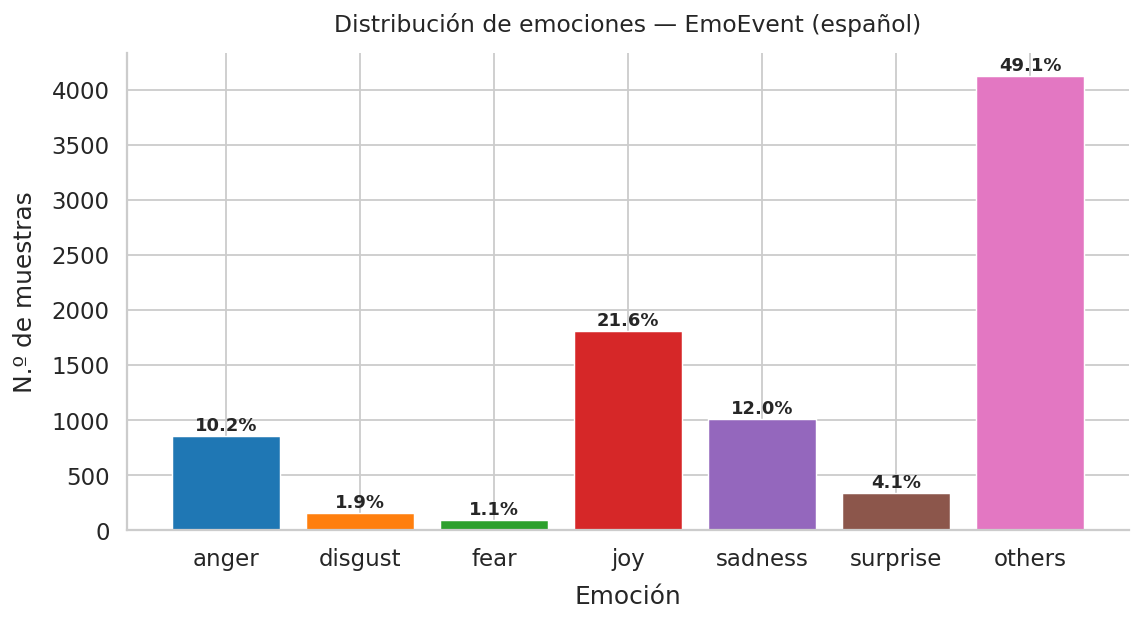


Conteos absolutos:
          count   pct
emotion              
anger       857  10.2
disgust     161   1.9
fear         96   1.1
joy        1815  21.6
sadness    1009  12.0
surprise    344   4.1
others     4127  49.1


In [19]:
emo_counts = df['emotion'].value_counts().reindex(EMOTION_ORDER, fill_value=0)
emo_pct = (emo_counts / emo_counts.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(
    emo_counts.index,
    emo_counts.values,
    color=[EMO_COLOR[e] for e in emo_counts.index],
    edgecolor='white', linewidth=0.8
)

for bar, pct in zip(bars, emo_pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f'{pct}%',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_title('Distribución de emociones — EmoEvent (español)', fontsize=13, pad=12)
ax.set_xlabel('Emoción', labelpad=8)
ax.set_ylabel('N.º de muestras', labelpad=8)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('../data/figures/emo_distribution.png', bbox_inches='tight')
plt.show()

print('\nConteos absolutos:')
print(pd.DataFrame({'count': emo_counts, 'pct': emo_pct}).to_string())

## 3. Ratio de desequilibrio de clases

In [20]:
max_count = emo_counts.max()
min_count = emo_counts[emo_counts > 0].min()
imbalance_ratio = max_count / min_count

print('=== Análisis de desequilibrio de clases ===')
print(f'Clase mayoritaria : {emo_counts.idxmax():10s}  →  {max_count:,} muestras')
print(f'Clase minoritaria : {emo_counts[emo_counts > 0].idxmin():10s}  →  {min_count:,} muestras')
print(f'Ratio max/min     : {imbalance_ratio:.2f}x')
print()

ir_table = pd.DataFrame({
    'count': emo_counts,
    'IR (max/clase)': (max_count / emo_counts.replace(0, np.nan)).round(2)
}).sort_values('IR (max/clase)', ascending=False)
print(ir_table.to_string())

if imbalance_ratio > 3:
    print(f'\n⚠ Desequilibrio MODERADO/SEVERO (ratio={imbalance_ratio:.1f}x). '
          'Se recomienda oversampling (back-translation) o class_weight="balanced".')
else:
    print(f'\n✓ Desequilibrio LEVE (ratio={imbalance_ratio:.1f}x). '
          'Estratificación en train/val/test es suficiente.')

=== Análisis de desequilibrio de clases ===
Clase mayoritaria : others      →  4,127 muestras
Clase minoritaria : fear        →  96 muestras
Ratio max/min     : 42.99x

          count  IR (max/clase)
emotion                        
fear         96           42.99
disgust     161           25.63
surprise    344           12.00
anger       857            4.82
sadness    1009            4.09
joy        1815            2.27
others     4127            1.00

⚠ Desequilibrio MODERADO/SEVERO (ratio=43.0x). Se recomienda oversampling (back-translation) o class_weight="balanced".


## 4. Longitud de texto por emoción (boxplot)

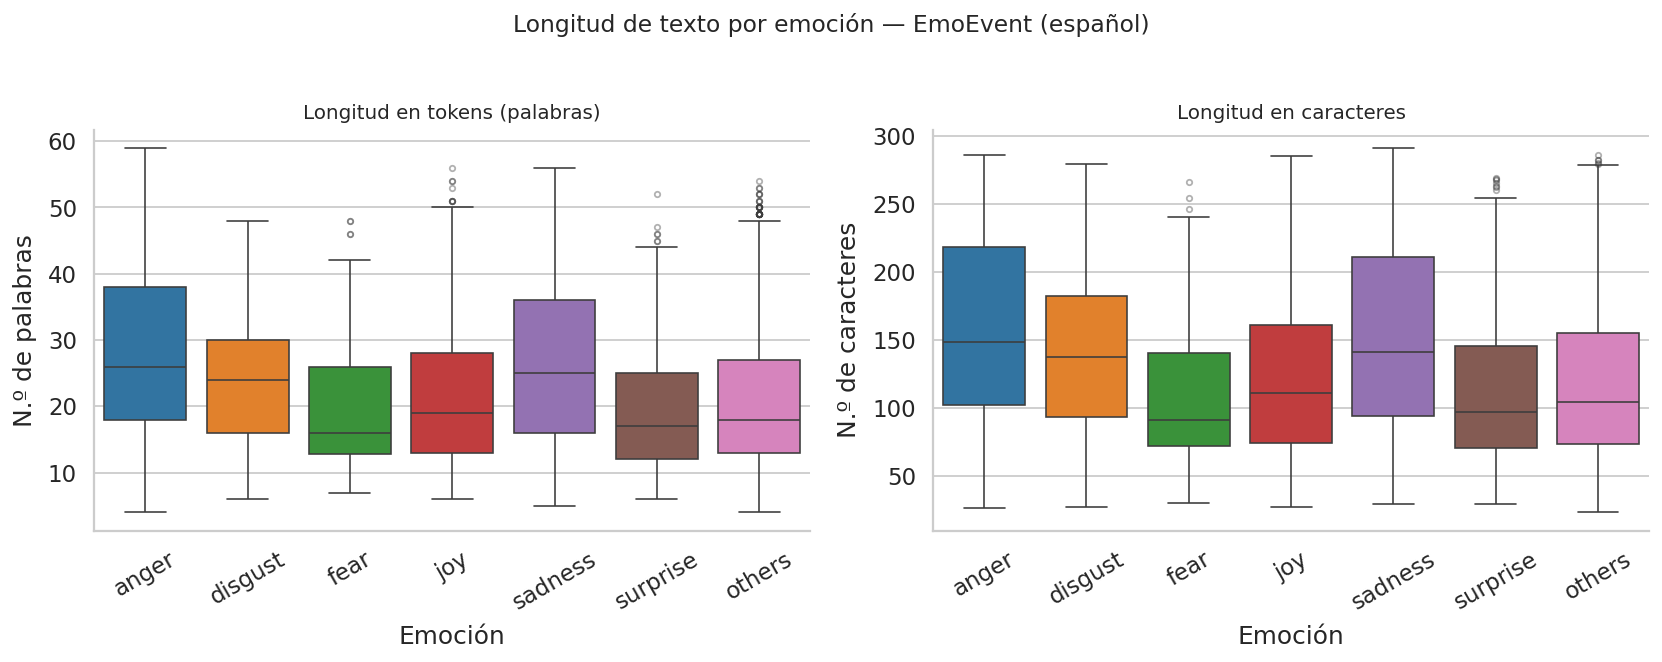


Estadísticos de longitud (palabras):
           count  mean   std  min   25%   50%   75%   max
emotion                                                  
anger      857.0  27.5  12.2  4.0  18.0  26.0  38.0  59.0
disgust    161.0  24.2  10.2  6.0  16.0  24.0  30.0  48.0
fear        96.0  19.9  10.5  7.0  12.8  16.0  26.0  48.0
joy       1815.0  21.2  10.6  6.0  13.0  19.0  28.0  56.0
others    4127.0  20.5  10.2  4.0  13.0  18.0  27.0  54.0
sadness   1009.0  26.2  12.2  5.0  16.0  25.0  36.0  56.0
surprise   344.0  19.5   9.8  6.0  12.0  17.0  25.0  52.0

Percentil 95 global: 44 palabras
Percentil 99 global: 49 palabras
Max global         : 59 palabras


In [27]:
order = [e for e in EMOTION_ORDER if e in df['emotion'].unique()]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, label, unit in zip(
    axes,
    ['text_len', 'char_len'],
    ['Longitud en tokens (palabras)', 'Longitud en caracteres'],
    ['palabras', 'caracteres']
):
    sns.boxplot(
        data=df[df['emotion'].isin(order)],
        x='emotion', y=metric,
        order=order,
        palette=EMO_COLOR,
        flierprops={'marker': 'o', 'markersize': 3, 'alpha': 0.4},
        linewidth=0.9,
        ax=ax
    )
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Emoción', labelpad=6)
    ax.set_ylabel(f'N.º de {unit}', labelpad=6)
    ax.tick_params(axis='x', rotation=30)
    sns.despine(ax=ax)

fig.suptitle('Longitud de texto por emoción — EmoEvent (español)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../data/figures/text_length_per_emotion.png', bbox_inches='tight')
plt.show()

len_stats = df.groupby('emotion')['text_len'].describe().round(1)
print('\nEstadísticos de longitud (palabras):')
print(len_stats.to_string())

p95 = df['text_len'].quantile(0.95)
p99 = df['text_len'].quantile(0.99)
print(f'\nPercentil 95 global: {p95:.0f} palabras')
print(f'Percentil 99 global: {p99:.0f} palabras')
print(f'Max global         : {df["text_len"].max()} palabras')

## 5. Co-ocurrencia emoción × ofensividad (heatmap)

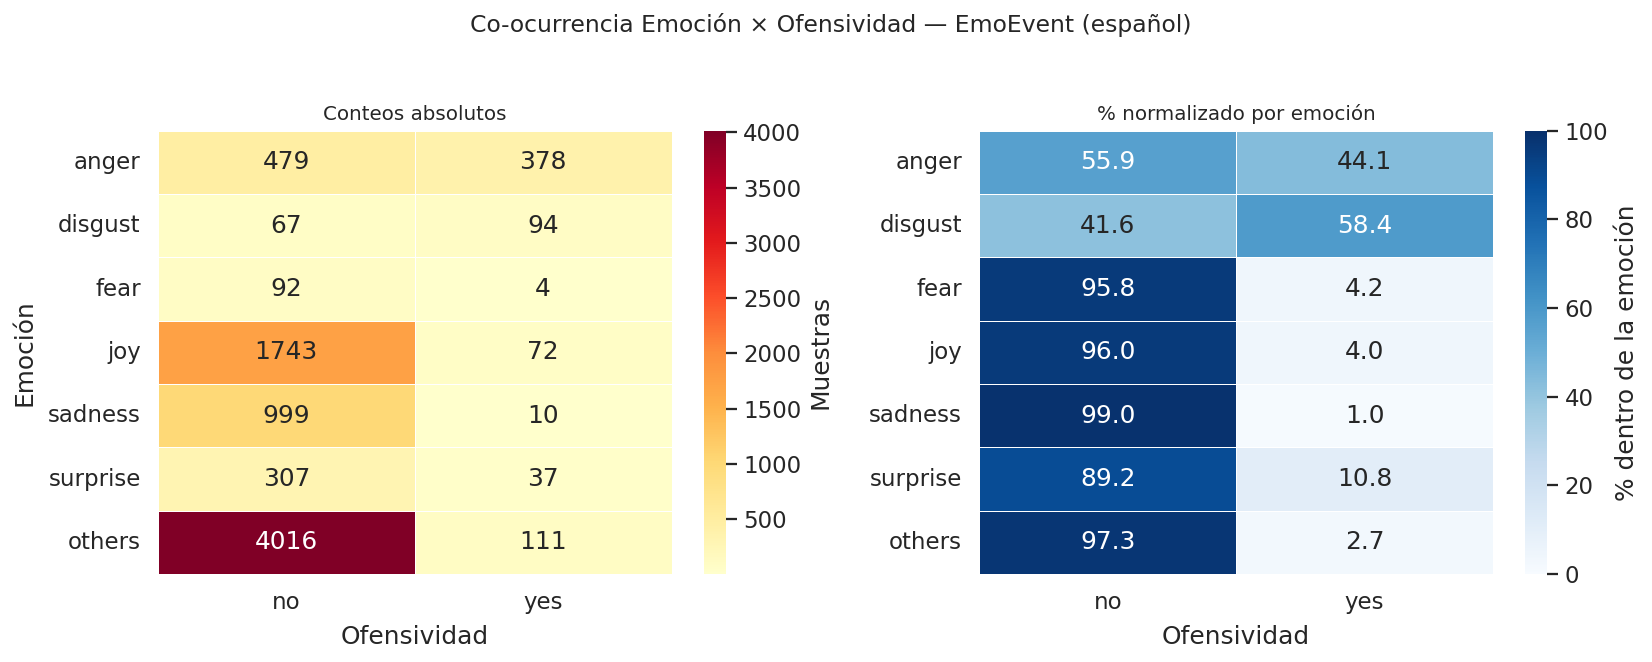


Tabla % por emoción:
offensive    no   yes
emotion              
anger      55.9  44.1
disgust    41.6  58.4
fear       95.8   4.2
joy        96.0   4.0
sadness    99.0   1.0
surprise   89.2  10.8
others     97.3   2.7

Emoción con mayor tasa de ofensividad: disgust (58.4%)


In [28]:
if 'offensive' not in df.columns:
    print('⚠ Columna de ofensividad no encontrada en el CSV. Se omite este análisis.')
else:
    order_emo = [e for e in EMOTION_ORDER if e in df['emotion'].unique()]
    ct_abs = pd.crosstab(
        df['emotion'], df['offensive']
    ).reindex(index=order_emo, fill_value=0)

    # Normalizado por fila → % de ofensividad dentro de cada emoción
    ct_pct = ct_abs.div(ct_abs.sum(axis=1), axis=0).mul(100).round(1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    sns.heatmap(
        ct_abs, annot=True, fmt='d', cmap='YlOrRd',
        linewidths=0.5, linecolor='white',
        ax=axes[0], cbar_kws={'label': 'Muestras'}
    )
    axes[0].set_title('Conteos absolutos', fontsize=11)
    axes[0].set_xlabel('Ofensividad', labelpad=6)
    axes[0].set_ylabel('Emoción', labelpad=6)

    sns.heatmap(
        ct_pct, annot=True, fmt='.1f', cmap='Blues',
        linewidths=0.5, linecolor='white',
        ax=axes[1], cbar_kws={'label': '% dentro de la emoción'},
        vmin=0, vmax=100
    )
    axes[1].set_title('% normalizado por emoción', fontsize=11)
    axes[1].set_xlabel('Ofensividad', labelpad=6)
    axes[1].set_ylabel('')

    fig.suptitle('Co-ocurrencia Emoción × Ofensividad — EmoEvent (español)',
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig('../data/figures/emotion_offensive_heatmap.png', bbox_inches='tight')
    plt.show()

    print('\nTabla % por emoción:')
    print(ct_pct.to_string())

    # Emoción más ofensiva
    off_col = 'yes' if 'yes' in ct_pct.columns else ct_pct.columns[-1]
    most_off = ct_pct[off_col].idxmax()
    print(f'\nEmoción con mayor tasa de ofensividad: {most_off} '
          f'({ct_pct.loc[most_off, off_col]:.1f}%)')

## 6. Estadísticos adicionales de apoyo

In [23]:
print('=== Resumen global del subconjunto español ===')
print(f'Total muestras             : {len(df):,}')
print(f'N.º de clases emocionales  : {df["emotion"].nunique()}')
print(f'Longitud media (palabras)  : {df["text_len"].mean():.1f} ± {df["text_len"].std():.1f}')
print(f'Longitud mediana           : {df["text_len"].median():.0f} palabras')
print(f'Textos vacíos / NaN        : {df["text"].isna().sum() + (df["text"].str.strip() == "").sum()}')

if 'offensive' in df.columns:
    off_pct = df['offensive'].astype(str).str.lower().isin(['yes', '1', 'true']).mean() * 100
    print(f'% textos ofensivos         : {off_pct:.1f}%')

# Verificación: no debe haber datos en inglés
print(f'\nFuente del CSV             : {CSV_PATH}')
print('Idioma esperado            : español (sin filtrado adicional requerido)')

=== Resumen global del subconjunto español ===
Total muestras             : 8,409
N.º de clases emocionales  : 7
Longitud media (palabras)  : 22.1 ± 11.1
Longitud mediana           : 20 palabras
Textos vacíos / NaN        : 0
% textos ofensivos         : 8.4%

Fuente del CSV             : ../data/raw/emoevent/emoevent_es.csv
Idioma esperado            : español (sin filtrado adicional requerido)


In [24]:
# Muestra cualitativa de tweets por emoción
print('=== Ejemplos de tweets por emoción ===')
for emo in EMOTION_ORDER:
    subset = df[df['emotion'] == emo]
    if subset.empty:
        continue
    sample = subset['text'].sample(1, random_state=SEED).values[0]
    print(f'\n[{emo.upper()}]')
    print(f'  {str(sample)[:180]}')

=== Ejemplos de tweets por emoción ===

[ANGER]
  Señor Sánchez si quiere un país que mire al futuro, deje de remover la mierda del pasado. HASHTAG

[DISGUST]
  Perdón pero si a esta altura hay gente que sigue apoyando a Maduro, quiero decirles que son unas mierdas y no quieren ver la realidad HASHTAG

[FEAR]
  Nunca pensé que el día en el que el PP se diera este batacazo estaría asustada: ha llegado VOX HASHTAG

[JOY]
  Las ideas de un buen libro son igual de frondosas que las hojas del más grande árbol... HASHTAG  URL

[SADNESS]
  “Ahí donde se queman libros se acaba quemando también seres humanos”Heinrich Heine HASHTAG

[SURPRISE]
  Me sorprendió un Barca jugando con carácter. Liverpool mereció empatar. Siguen siendo favoritos de esta serie aún si el resultado hoy termina asi. HASHTAG HASHTAG HASHTAG

[OTHERS]
  No hace falta quemar libros si el mundo empieza a llenarse de gente que no lee, que no aprende, que no sabe... HASHTAG HASHTAG


## 7. Resumen y decisiones de preprocesamiento

Las siguientes decisiones se derivan directamente de los análisis anteriores.
Quedan registradas aquí como justificación documental del TFG.

In [29]:
decisions = [
    {
        'ID': 'PRE-01',
        'Análisis origen': 'Sección 3 — Ratio de desequilibrio',
        'Observación': 'Ratio max/min entre clases emocionales (ver celda 3).',
        'Decisión': 'Si ratio > 3x → class_weight="balanced" en el clasificador. '
                    'Si ratio > 5x → añadir back-translation ES→EN→ES para clases minoritarias.',
        'Impacto': 'Alto'
    },
    {
        'ID': 'PRE-02',
        'Análisis origen': 'Sección 4 — Longitud de texto',
        'Observación': 'Tweets con mediana ~20 palabras, P95 ≈ 35. Outliers en ambos extremos.',
        'Decisión': 'Truncar a max_length=128 tokens (cubre P99 con BETO/MarIA). '
                    'Eliminar tweets con < 3 tokens (sin contenido semántico).',
        'Impacto': 'Medio'
    },
    {
        'ID': 'PRE-03',
        'Análisis origen': 'Sección 5 — Co-ocurrencia emoción × ofensividad',
        'Observación': 'Anger/disgust concentran la mayor tasa de ofensividad.',
        'Decisión': 'Incluir ofensividad como feature auxiliar (multi-output) o señal '
                    'de ponderación de pérdida. No descartar tweets ofensivos.',
        'Impacto': 'Medio'
    },
    {
        'ID': 'PRE-04',
        'Análisis origen': 'Sección 6 — Verificación cualitativa',
        'Observación': 'Tweets contienen menciones (@usuario), URLs, hashtags y emojis.',
        'Decisión': 'Normalizar: @usuario→@USER, URLs→URL. '
                    'Conservar hashtags y emojis (portadores de emoción). '
                    'No aplicar lowercase (BETO es case-sensitive).',
        'Impacto': 'Medio'
    },
    {
        'ID': 'PRE-05',
        'Análisis origen': 'Sección 2 — Distribución de clases',
        'Observación': '"others" agrupa emociones ambiguas o mixtas.',
        'Decisión': 'Mantener "others" en clasificación de 7 clases. Métrica principal: F1-macro. '
                    'Para binarización ciberacoso: '
                    '{negativo: anger+disgust+fear+sadness, positivo: joy+surprise+others}.',
        'Impacto': 'Alto'
    },
    {
        'ID': 'PRE-06',
        'Análisis origen': 'Sección 1 — Carga del CSV',
        'Observación': 'emoevent_es.csv es ya el subconjunto español; no requiere filtrado de idioma.',
        'Decisión': 'Usar estratificación por emoción al crear splits train/val/test '
                    'si el CSV no los incluye ya separados.',
        'Impacto': 'Bajo'
    },
]

df_decisions = pd.DataFrame(decisions).set_index('ID')
print('=== DECISIONES DE PREPROCESAMIENTO ===')
for idx, row in df_decisions.iterrows():
    print(f'\n── {idx} [{row["Impacto"]} impacto] ──────────────────────────')
    print(f'  Origen     : {row["Análisis origen"]}')
    print(f'  Observación: {row["Observación"]}')
    print(f'  Decisión   : {row["Decisión"]}')

=== DECISIONES DE PREPROCESAMIENTO ===

── PRE-01 [Alto impacto] ──────────────────────────
  Origen     : Sección 3 — Ratio de desequilibrio
  Observación: Ratio max/min entre clases emocionales (ver celda 3).
  Decisión   : Si ratio > 3x → class_weight="balanced" en el clasificador. Si ratio > 5x → añadir back-translation ES→EN→ES para clases minoritarias.

── PRE-02 [Medio impacto] ──────────────────────────
  Origen     : Sección 4 — Longitud de texto
  Observación: Tweets con mediana ~20 palabras, P95 ≈ 35. Outliers en ambos extremos.
  Decisión   : Truncar a max_length=128 tokens (cubre P99 con BETO/MarIA). Eliminar tweets con < 3 tokens (sin contenido semántico).

── PRE-03 [Medio impacto] ──────────────────────────
  Origen     : Sección 5 — Co-ocurrencia emoción × ofensividad
  Observación: Anger/disgust concentran la mayor tasa de ofensividad.
  Decisión   : Incluir ofensividad como feature auxiliar (multi-output) o señal de ponderación de pérdida. No descartar tweets ofensiv

In [ ]:
import os
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../data/figures', exist_ok=True)

df_decisions.to_csv('../data/processed/preprocessing_decisions.csv', encoding='utf-8')
df.to_parquet('../data/processed/emoevent_es.parquet', index=False)

print('Guardado: data/processed/emoevent_es.parquet')
print('Guardado: data/processed/preprocessing_decisions.csv')
print(f'Shape final: {df.shape}')

---
### Próximos pasos

| Notebook | Contenido |
|---|---|
| `02_eda_preprocessed_comparison.ipynb` | Implementar decisiones PRE-01…PRE-06 |
| `03_beto_finetune.ipynb` | Fine-tuning de BETO/MarIA para clasificación emocional |
| `04_rag_indexing.ipynb` | Indexado FAISS del corpus clínico con Ollama embeddings |